In [7]:
import torch
import random

# --- Hyperparameters ---
L = 16               # number of spins (we’ll do 1D for simplicity; extend to 2D if you like)
K = 1.0              # 4-spin coupling strength
n_steps = 100_000    # total MCMC steps
beta = .5           # inverse temperature

# --- Initialize random spins ±1 ---
spins = torch.randint(0, 2, (L,), dtype=torch.float32) * 2 - 1  # shape (L,)

def energy(s):
    # Here we pick plaquettes of size 4 along the 1D ring; for 2D just sum over 2×2 loops
    # with periodic boundary conditions.
    e = 0.0
    for i in range(L):
        # indices of a “plaquette” in 1D: i, i+1, i+2, i+3 mod L
        a, b, c, d = s[i], s[(i+1)%L], s[(i+2)%L], s[(i+3)%L]
        e += -K * (a * b * c * d)
    return e

# Precompute initial energy
E = energy(spins)

samples = []
for step in range(n_steps):
    # Propose flip
    i = random.randrange(L)
    s_new = spins.clone()
    s_new[i] *= -1
    E_new = energy(s_new)
    dE = E_new - E
    # Metropolis accept
    if dE <= 0 or torch.rand(1).exp() < torch.exp(-beta * dE):
        spins = s_new
        E = E_new
    # Record a sample every L steps
    if step % L == 0:
        samples.append(spins.clone())

# Convert to tensor of shape (n_samples, L)
samples = torch.stack(samples)
print("Collected", samples.shape[0], "samples")

Collected 6250 samples


In [8]:
samples.shape

torch.Size([6250, 16])

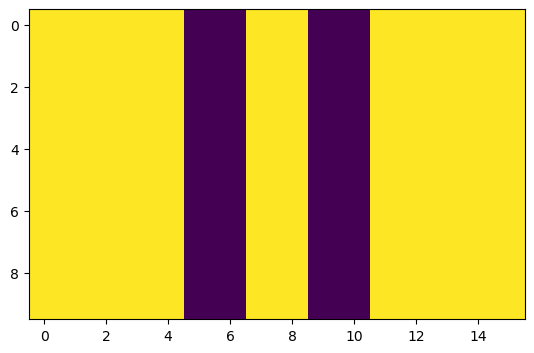

In [9]:
import torch
import matplotlib.pyplot as plt

plt.imshow(samples[100:200:10])